In [9]:
from src.TimeSeriesAnalysis import read_experiment_json, select_random_json
from src.network_animation import *
import matplotlib.pyplot as plt
import numpy as np
import os
plt.style.use('properties.mplstyle')

../SOP_data/raw/bond_percolation_equilibration/num_colors_4/dim_3/L_256/NT_constant/NT_655/k_1.0e-06/rho_2.5000e-01/data_equilibration/light_seed_44_ts_20260422T155829_P0_0.10_p0_1.00_process.json


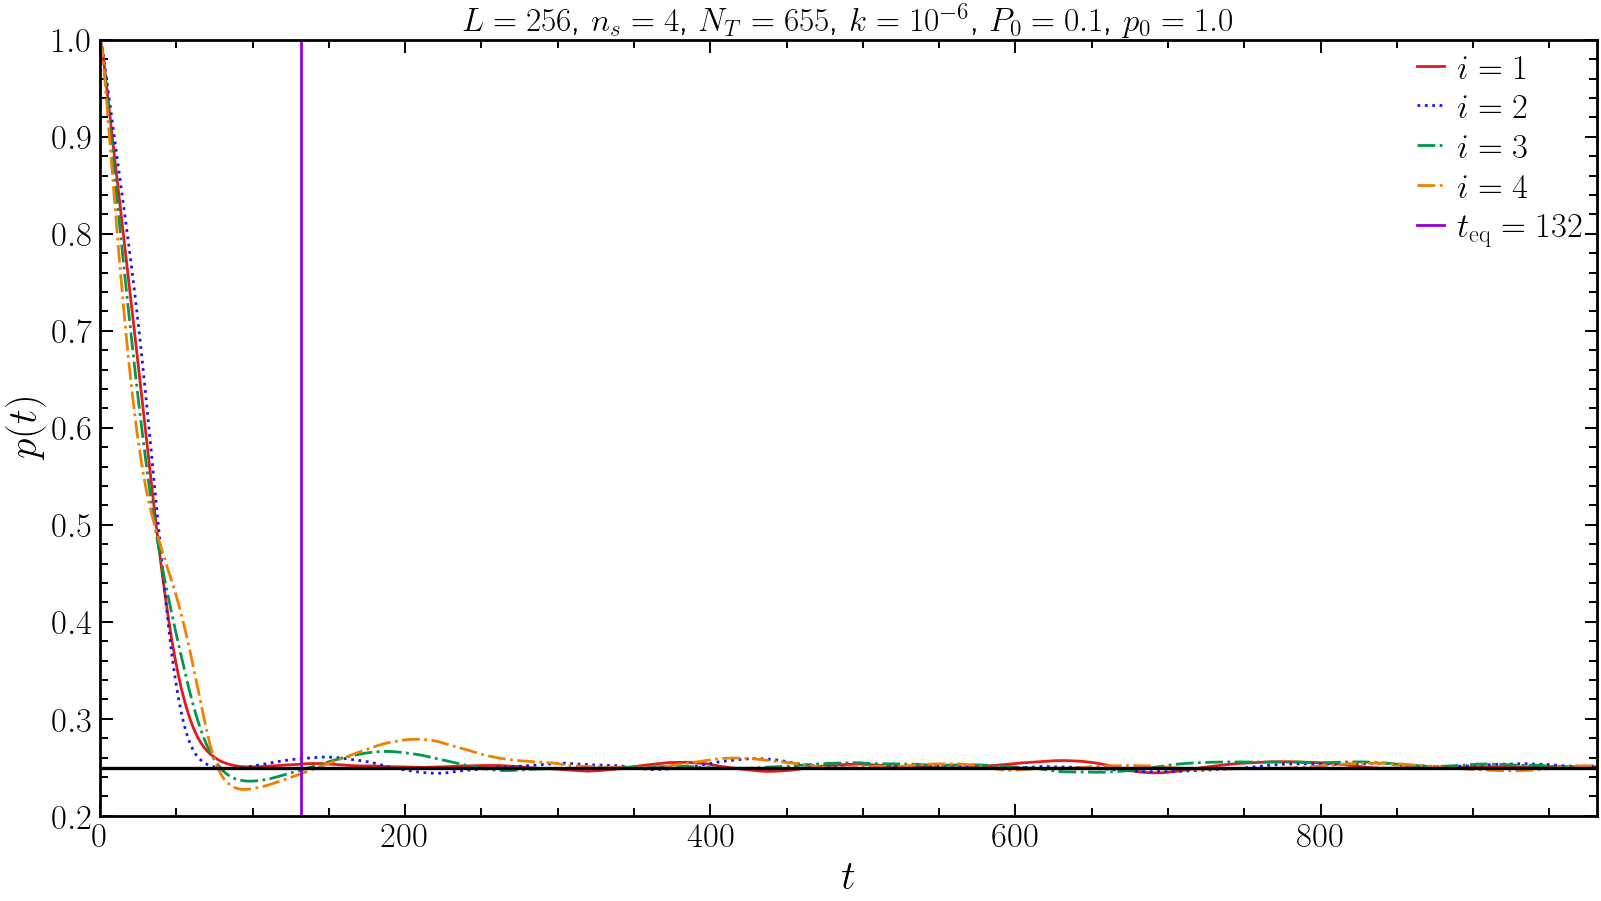

In [48]:
nc = 4
L = 256
NT = 655
k = 1.0e-06
rho = 1/nc
dim = 3
p0 = 1.0
P0 = 0.1
path = f"../SOP_data/raw/bond_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/data/"
fs = path + "light_seed_44_ts_20260422T155829_P0_0.10_p0_1.00.json"
data = read_experiment_json(fs)
t_eq = data['meta']['t_eq']

path_Eq = f"../SOP_data/raw/bond_percolation_equilibration/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{NT}/k_{k:.1e}/rho_{rho:.4e}/data_equilibration/"
f_base = os.path.basename(fs)
fs_Eq = path_Eq + f_base[:-5] + "_process.json"
print(fs_Eq)
fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)

order_raw = [i for i in range(1,nc+1)]
ls = ['solid', 'dotted', 'dashdot','-.']
lw=  2.0
fs_label = 30
fs_ticks = 25

colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]

t_max_min  = min(max(data['results'][f'order_percolation {i}']['data']['time']) for i in order_raw)
pc = 0.24881182
for idx, i in enumerate(order_raw):
    pt = data['results'][f'order_percolation {i}']['data']['pt']
    t  = data['results'][f'order_percolation {i}']['data']['time']

    ax.plot(t, pt, ls=ls[idx],  lw=lw, color=colors[idx], label=f"$i = {i}$")


mantissa, exp = f"{k:.1e}".split("e")
ax.set_xlim(0,t_max_min)
ax.set_ylim(0.2,1.0)
ax.axvline(x=t_eq,color='darkviolet',lw=lw, label = fr'$t_{{\mathrm{{eq}}}} = {t_eq}$')
ax.axhline(y=pc, color='k',lw=1.2*lw)
ax.legend(fontsize=25)
ax.set_xlabel(r'$t$', fontsize=fs_label)
ax.set_ylabel(r'$p(t)$', fontsize=fs_label)
ax.set_title(f'$L = {L}$, $n_s = {nc}$, $N_T = {NT}$, $k = 10^{{{int(exp)}}}$, $P_0 = 0.1$, $p_0 = 1.0$')
ax.tick_params(axis='both', labelsize=fs_ticks)
plt.savefig(f"../results/TimeSeries/3D/Time_Equilibration_L{L}_ns{nc}.png")
plt.show()


In [48]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fn = "/home/light/Documents/self_organization_percolation/SOP_data/raw/bond_percolation/num_colors_4/dim_3/L_256/NT_constant/NT_655/k_1.0e-06/rho_2.5000e-01/data_surfaces/light_seed_44_ts_20260422T133857_P0_0.10_p0_1.00.npz"
data = np.load(fn)

surface_pre = data["surface_preteq"]
surface_post = data["surface_posteq"]

x_pre, y_pre, z_pre, c_pre = surface_pre.T
x_post, y_post, z_post, c_post = surface_post.T

x_pre = x_pre.astype(int)
y_pre = y_pre.astype(int)
z_pre = z_pre.astype(float)
c_pre = c_pre.astype(int)

x_post = x_post.astype(int)
y_post = y_post.astype(int)
z_post = z_post.astype(float)
c_post = c_post.astype(int)

# --------------------------------------------------
# monta grid regular Z(y,x) e C(y,x)
# --------------------------------------------------
def build_surface_grid(x, y, z, c):
    nx = x.max() + 1
    ny = y.max() + 1

    Z = np.full((ny, nx), np.nan, dtype=float)
    C = np.full((ny, nx), np.nan, dtype=float)

    Z[y, x] = z
    C[y, x] = c

    return Z, C

Z_pre, C_pre = build_surface_grid(x_pre, y_pre, z_pre, c_pre)
Z_post, C_post = build_surface_grid(x_post, y_post, z_post, c_post)

# --------------------------------------------------
# cores discretas por espécie
# --------------------------------------------------
# 0 -> red, 1 -> blue, 2 -> green, 3 -> orange
species_colorscale = [
    [0.00, "red"],
    [0.249999, "red"],
    [0.25, "blue"],
    [0.499999, "blue"],
    [0.50, "green"],
    [0.749999, "green"],
    [0.75, "orange"],
    [1.00, "orange"],
]

def normalize_species(C):
    cmin = np.nanmin(C)
    cmax = np.nanmax(C)
    if cmax == cmin:
        return np.zeros_like(C, dtype=float)
    return (C - cmin) / (cmax - cmin)

C_pre_norm = normalize_species(C_pre)
C_post_norm = normalize_species(C_post)

# eixos
x_axis_pre = np.arange(Z_pre.shape[1])
y_axis_pre = np.arange(Z_pre.shape[0])

x_axis_post = np.arange(Z_post.shape[1])
y_axis_post = np.arange(Z_post.shape[0])

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "surface"}, {"type": "surface"}]],
    subplot_titles=("Surface PRETEQ", "Surface POSTEQ"),
    horizontal_spacing=0.03
)

fig.add_trace(
    go.Surface(
        z=Z_pre,
        x=x_axis_pre,
        y=y_axis_pre,
        surfacecolor=C_pre_norm,
        colorscale=species_colorscale,
        cmin=0.0,
        cmax=1.0,
        showscale=False
    ),
    row=1, col=1
)

fig.add_trace(
    go.Surface(
        z=Z_post,
        x=x_axis_post,
        y=y_axis_post,
        surfacecolor=C_post_norm,
        colorscale=species_colorscale,
        cmin=0.0,
        cmax=1.0,
        showscale=False
    ),
    row=1, col=2
)

scene_common = dict(
    xaxis=dict(title="X"),
    yaxis=dict(title="Y"),
    zaxis=dict(title="Z"),
    aspectmode="cube"
)

fig.update_layout(
    width=1500,
    height=700,
    scene=scene_common,
    scene2=scene_common,
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

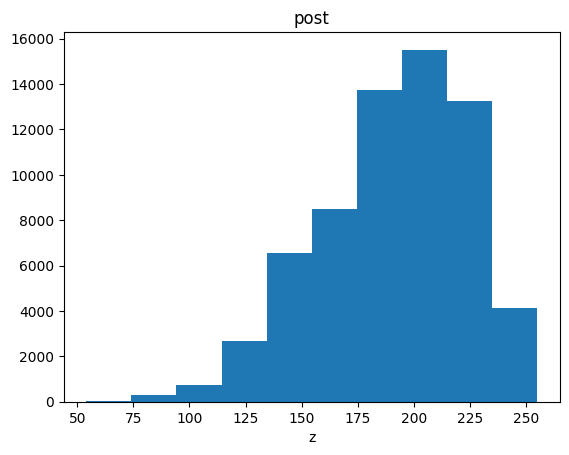

In [47]:

plt.hist(z_post)
plt.xlabel('z')
plt.title("post")
plt.show()

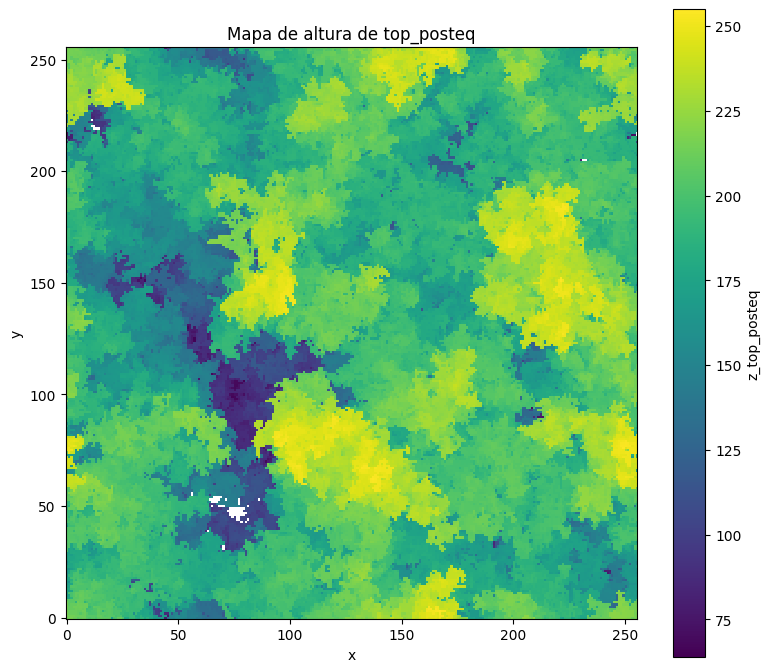

In [12]:
import numpy as np
import matplotlib.pyplot as plt

fn = "/home/light/Documents/self_organization_percolation/SOP_data/raw/bond_percolation/num_colors_4/dim_3/L_256/NT_constant/NT_655/k_1.0e-06/rho_2.5000e-01/data_surfaces/light_seed_11_ts_20260422T124831_P0_0.10_p0_1.00.npz"
data = np.load(fn)

top_post = data["top_posteq"]
x, y, z, c = top_post.T
x = x.astype(int)
y = y.astype(int)
z = z.astype(int)

Lx = x.max() + 1
Ly = y.max() + 1

H = np.full((Ly, Lx), np.nan)
H[y, x] = z

plt.figure(figsize=(8, 7))
im = plt.imshow(H, origin="lower", cmap="viridis", interpolation="nearest")
plt.colorbar(im, label="z_top_posteq")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Mapa de altura de top_posteq")
plt.tight_layout()
plt.show()

(array([  192.,  1295.,  1390.,  1777.,  3780.,  8249., 18818., 15582.,
         9453.,  4926.]),
 array([ 64. ,  83.1, 102.2, 121.3, 140.4, 159.5, 178.6, 197.7, 216.8,
        235.9, 255. ]),
 <BarContainer object of 10 artists>)

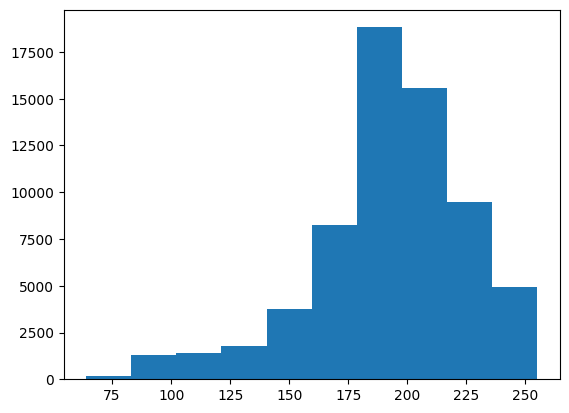

In [14]:
plt.hist(z)

In [6]:
import numpy as np
L = 256
def ler_rede_npz(caminho, reconstruir_rede=False, retornar_coords=False):
    """
    Lê um arquivo .npz de rede esparsa.

    Parâmetros
    ----------
    caminho : str
        Caminho do arquivo .npz
    reconstruir_rede : bool, opcional
        Se True, reconstrói a rede densa completa.
    retornar_coords : bool, opcional
        Se True, também retorna as coordenadas (x,y,z,...) dos índices ativos.

    Retorna
    -------
    dict
        Dicionário com metadados e arrays lidos do arquivo.
    """
    with np.load(caminho, allow_pickle=False) as arq:
        dim = int(arq["dim"])
        num_colors = int(arq["num_colors"])
        seed = int(arq["seed"])
        shape = tuple(int(x) for x in arq["shape"])
        rho = arq["rho"].astype(float, copy=False)
        active_idx = arq["active_idx"].astype(np.int64, copy=False)
        active_val = arq["active_val"].astype(np.int32, copy=False)

    out = {
        "dim": dim,
        "num_colors": num_colors,
        "seed": seed,
        "shape": shape,
        "rho": rho,
        "active_idx": active_idx,
        "active_val": active_val,
        "num_active": len(active_idx),
    }

    if retornar_coords:
        coords = np.column_stack(np.unravel_index(active_idx, shape))
        out["coords"] = coords

    if reconstruir_rede:
        rede = np.zeros(shape, dtype=active_val.dtype)
        rede.flat[active_idx] = active_val
        out["rede"] = rede

    return out
path = "/home/light/Documents/self_organization_percolation/SOP_data/raw/bond_percolation_equilibration/num_colors_8/dim_3/L_256/NT_constant/NT_655/k_1.0e-06/rho_1.2500e-01/network/"
fn = path + "light_seed_7978782_ts_20260420T143749_P0_0.10_p0_1.00.npz"
dados = ler_rede_npz(fn, reconstruir_rede=False, retornar_coords=True)

print("dim =", dados["dim"])
print("num_colors =", dados["num_colors"])
print("seed =", dados["seed"])
print("shape =", dados["shape"])
print("rho =", dados["rho"])
print("num_active =", dados["num_active"])
print("num_total =", L**3)
print("fraction_active = ", dados["num_active"]/L**3)
print("primeiros índices ativos =", dados["active_idx"][:10])
print("primeiros valores ativos =", dados["active_val"][:10])
print("primeiras coordenadas =", dados["coords"][:10])


dim = 3
num_colors = 8
seed = -1
shape = (256, 256, 256)
rho = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
num_active = 9390294
num_total = 16777216
fraction_active =  0.5597051382064819
primeiros índices ativos = [0 1 2 3 4 5 6 7 8 9]
primeiros valores ativos = [10000000 10000001 10000002 10000001 10000000 10000001 10000002 10000003
 50000003 50000002]
primeiras coordenadas = [[0 0 0]
 [0 0 1]
 [0 0 2]
 [0 0 3]
 [0 0 4]
 [0 0 5]
 [0 0 6]
 [0 0 7]
 [0 0 8]
 [0 0 9]]


In [3]:
import numpy as np

def ler_arquivo_npz(caminho, reconstruir_rede=False):
    """
    Lê um arquivo .npz de rede salva em formato esparso.

    Parâmetros
    ----------
    caminho : str
        Caminho do arquivo .npz
    reconstruir_rede : bool
        Se True, reconstrói a rede densa completa.

    Retorna
    -------
    dict
        Dicionário com os dados lidos.
    """
    with np.load(caminho, allow_pickle=False) as arq:
        dados = {chave: arq[chave] for chave in arq.files}

    out = {
        "dim": int(dados["dim"]),
        "num_colors": int(dados["num_colors"]),
        "seed": int(dados["seed"]),
        "shape": tuple(dados["shape"]),
        "rho": dados["rho"],
        "active_idx": dados["active_idx"],
        "active_val": dados["active_val"],
    }

    if reconstruir_rede:
        rede = np.zeros(out["shape"], dtype=out["active_val"].dtype)
        rede.flat[out["active_idx"]] = out["active_val"]
        out["rede"] = rede

    return out

In [5]:
dados = ler_arquivo_npz(fn, reconstruir_rede=True)

print("dim =", dados["dim"])
print("shape =", dados["shape"])
print("seed =", dados["seed"])
print("rho =", dados["rho"])
print("primeiros índices =", dados["active_idx"][:10])
print("primeiros valores =", dados["active_val"][:10])
print("unique da rede =", np.unique(dados["rede"]))

dim = 3
shape = (np.int32(256), np.int32(256), np.int32(256))
seed = -1
rho = [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
primeiros índices = [0 1 2 3 4 5 6 7 8 9]
primeiros valores = [10000000 10000001 10000002 10000001 10000000 10000001 10000002 10000003
 50000003 50000002]
unique da rede = [       0 10000000 10000001 ... 80000633 80000634 80000635]
